In [1]:
import numpy as np 
import pandas as pd 

## Data Loading

In [2]:
dms=pd.read_csv("/kaggle/input/datasets/lovishbansal123/diamond-dataset/diamonds.csv")
dms.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
dms=dms.drop(
    columns = ["Unnamed: 0"]
)

## Data Preprocessing and Cleaning

In [4]:
cut_mapping = {
    "Fair": 1,
    "Good": 2,
    "Very Good": 3,
    "Premium": 4,
    "Ideal": 5
}
color_mapping = {
    "J": 1,
    "I": 2,
    "H": 3,
    "G": 4,
    "F": 5,
    "E": 6,
    "D": 7
}
clarity_mapping = {
    "I1": 1,
    "SI2": 2,
    "SI1": 3,
    "VS2": 4,
    "VS1": 5,
    "VVS2": 6,
    "VVS1": 7,
    "IF": 8
}
dms["cut"] = dms["cut"].map(cut_mapping)
dms["color"] = dms["color"].map(color_mapping)
dms["clarity"] = dms["clarity"].map(clarity_mapping)

In [5]:
dms.duplicated().sum()
dms.drop_duplicates(inplace=True)

## Exploring The Dataset

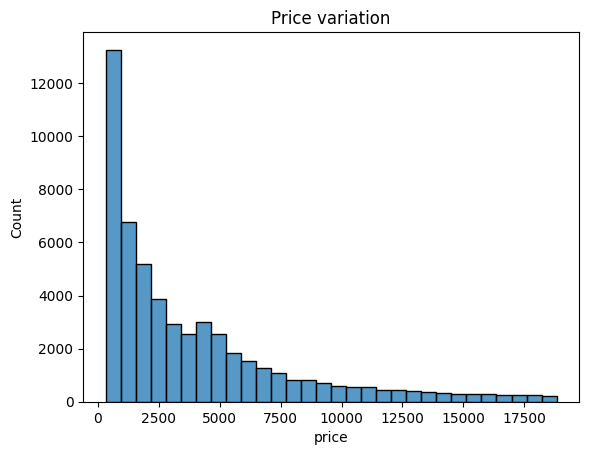

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(dms["price"], bins=30)
plt.title("Price variation")
plt.show()

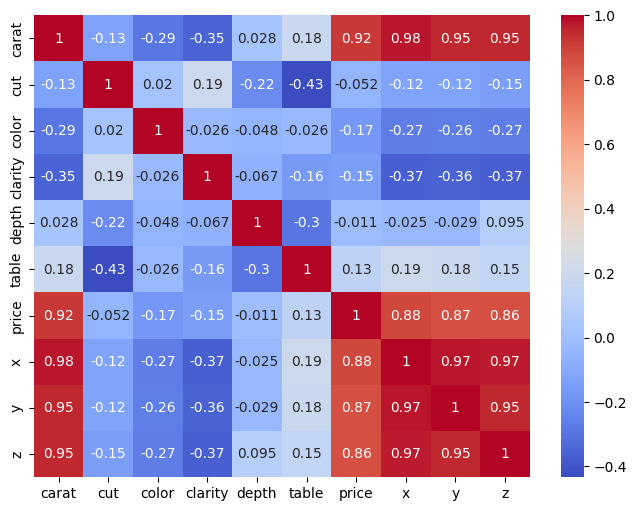

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(
    dms.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Data Splitting

In [8]:
x = dms.drop('price', axis=1)
y = dms['price']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

## Model Evaluation Function

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, x_train, x_test, y_train, y_test):
    y_pred = model.predict(x_test)
    r2=r2_score(y_test,y_pred)
    print(f"Train R² : {model.score(x_train, y_train):}")
    print(f"Test R²  : {model.score(x_test, y_test):}")
    print(f"R-squared: {r2}")
    print(f"MAE      : {mean_absolute_error(y_test, y_pred):}")
    print(f"MSE      : {mean_squared_error(y_test, y_pred):}")
    print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred)):}")

## Linear Regression

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
scaler = StandardScaler()
x_trains = scaler.fit_transform(x_train)
x_tests = scaler.fit_transform(x_test)
lr = LinearRegression()
lr.fit(x_trains, y_train)
y_pred=lr.predict(x_tests)
evaluate_model(lr, x_trains, x_tests, y_train, y_test)

Train R² : 0.9068855797014883
Test R²  : 0.9071446046836686
R-squared: 0.9071446046836686
MAE      : 801.697346774307
MSE      : 1415308.4555925413
RMSE     : 1189.6673718281684


## Random Forest Regressor

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=parameters,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42
)
random_search.fit(x_train, y_train)

best_rf = random_search.best_estimator_
evaluate_model(best_rf, x_train, x_test, y_train, y_test)

Train R² : 0.9966956117981473
Test R²  : 0.9825147988983811
R-squared: 0.9825147988983811
MAE      : 261.1170871485573
MSE      : 266510.6629781882
RMSE     : 516.2467074744285


## XGBoost Regressor

In [12]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    random_state=42
)

parameters = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=parameters,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

best_xgb = random_search.best_estimator_
evaluate_model(best_xgb, x_train, x_test, y_train, y_test)

Train R² : 0.9868966341018677
Test R²  : 0.9835997223854065
R-squared: 0.9835997223854065
MAE      : 263.79522705078125
MSE      : 249973.921875
RMSE     : 499.9739211948959


##### As XGBoost r-squared score is the highest, it is choosen as the best model.

### Feature Importance Analysis

In [13]:
importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=True)

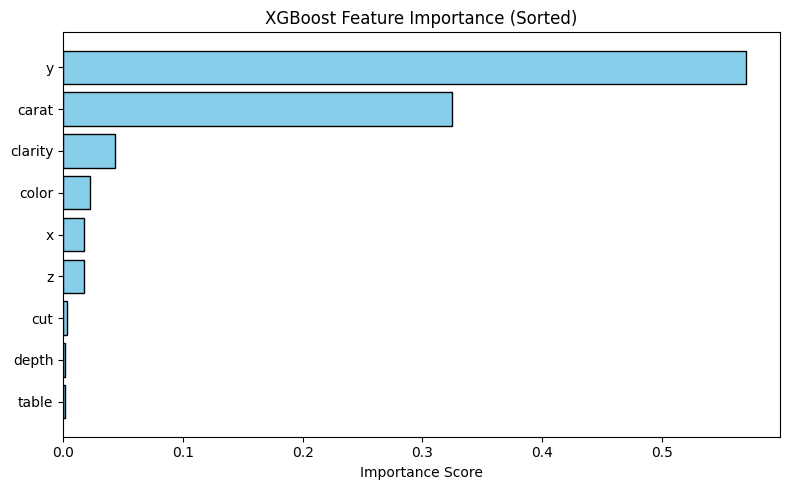

In [14]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
plt.title("XGBoost Feature Importance (Sorted)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### Residual Analysis and Target Transformation

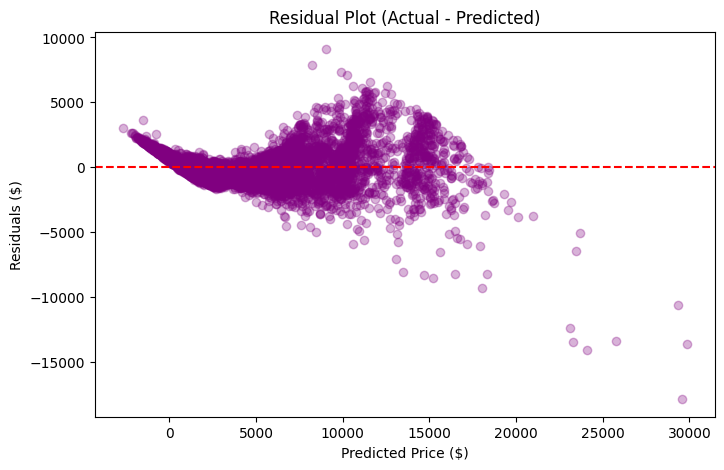

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Actual - Predicted)")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals ($)")
plt.show()

##### The above graph shows that in the case of highly expensive diamonds, the error in prediction tends to be more. This occurs because the dataset contains a vsry small number of highly priced diamonds. Since the model focuses more on minimizing errors for the majority of data, it struggles to accurately predict these extreme values.

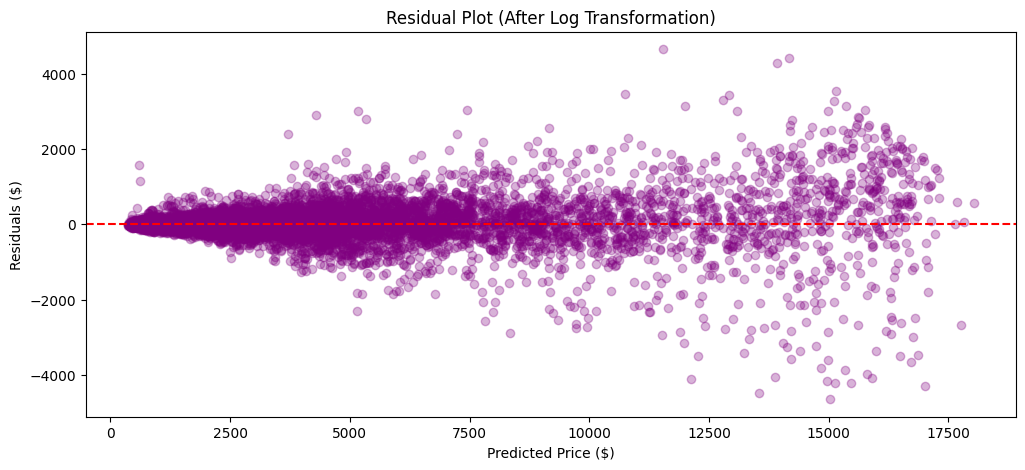

In [16]:
y_train_log = np.log1p(y_train)

best_xgb.fit(x_train, y_train_log)

y_pred_log = best_xgb.predict(x_test)
y_pred = np.expm1(y_pred_log)

residuals = y_test - y_pred

plt.figure(figsize=(12, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (After Log Transformation)")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals ($)")
plt.show()

##### To reduce this skewness and stabilize the variance, I applied logarithmic transformation to the target-Price. The large price values are contained while the relative order is contained. The distribution becomes balanced.

In [17]:
evaluate_model(best_xgb, x_train, x_test, y_train_log, np.log1p(y_test))

Train R² : 0.9932361369610748
Test R²  : 0.9919464870457333
R-squared: 0.9919464870457333
MAE      : 0.06576006602277623
MSE      : 0.008067713239056536
RMSE     : 0.08982045000475412


In [18]:
y_pred_log = best_xgb.predict(x_test)
y_pred = np.expm1(y_pred_log)

print(f"Dollar R²  : {r2_score(y_test, y_pred):.4f}")
print(f"Dollar MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Dollar MSE : {mean_squared_error(y_test, y_pred):.2f}")
print(f"Dollar RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Dollar R²  : 0.9829
Dollar MAE : 261.09
Dollar MSE : 260977.95
Dollar RMSE: 510.86


## Checking Accuracy

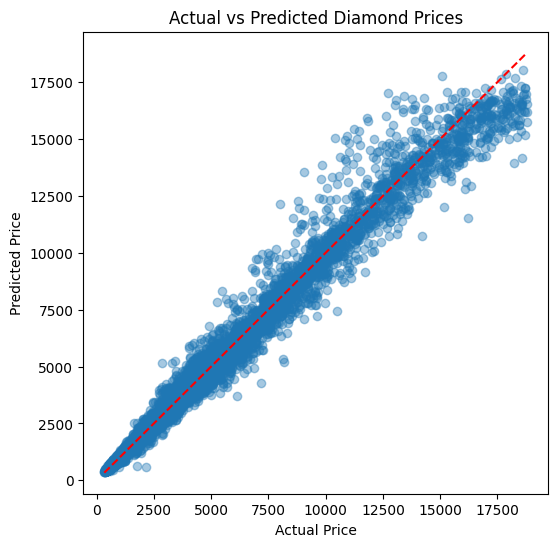

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Diamond Prices")
plt.show()

## Final Model Export

In [20]:
best_xgb.save_model("diamond_price_model.json")